In [1]:
import pandas as pd

df = pd.read_csv(
    "C:\\Users\\loloa\\OneDrive\\Escritorio\\facu\\Ciencia de datos\\trabajo_final\\TP-Final-Ciencia-de-Datos\\Base Aprender Estudiantes 6 Grado Primaria 2023 (3).csv",
    sep=";",       # si no funciona con "," probá con ";"
    encoding="latin1"  # si no funciona, probá "utf-8"
)

In [2]:
import numpy as np
df["ap23"] = pd.to_numeric(df["ap23"], errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})

df["sobreedad"] = pd.to_numeric(df["sobreedad"], errors="coerce").replace({
    -9: np.nan,  # blanco -> NA
    0: 0,        # menor o edad teórica -> 0
    1: 0,        # idem
    2: 1,        # 1 año de sobreedad
    3: 2,        # 2 años
    4: 3         # 3 años o más
})

df["migracion"] = pd.to_numeric(df["migracion"], errors="coerce").replace({
    -9: np.nan,   # valores faltantes
    2: 0          # 2 -> no migrante
    # 1 queda como migrante (1)
})

cols_desemp = ["ldesemp", "mdesemp"]
df[cols_desemp] = df[cols_desemp].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})


# Reemplazar -9, -8, -6 por NaN
col_ap26=["ap26"]
df[col_ap26] = df[col_ap26].replace({-9: np.nan, -8: np.nan, -6: np.nan})
cols_ap21_22 = ["ap22"]
df[cols_ap21_22] = df[cols_ap21_22].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})
cols_ap18_19 = [f"ap18{c}" for c in list("abcd")] + [f"ap19{c}" for c in list("abcd")]

df[cols_ap18_19] = df[cols_ap18_19].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})
cols_ap10_15 = ["ap10", "ap11", "ap12", "ap13", "ap14", "ap15"]

df[cols_ap10_15] = df[cols_ap10_15].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})
ap09_cols = [f"ap09{c}" for c in list("abcdefghijk")]
df[ap09_cols] = df[ap09_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})
ap07_cols = ["ap07a", "ap07b"]

df[ap07_cols] = df[ap07_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})
ap06_cols = [f"ap06{c}" for c in list("abcde")]

# Limpiar valores inválidos
df[ap06_cols] = df[ap06_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

df["ap03"] = pd.to_numeric(df["ap03"], errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})
#df = df.dropna(subset=["ap03"])  # eliminar filas con NaN
cols = ["sector", "ambito", "ap01"]

df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})

In [3]:
import numpy as np
import pandas as pd

def fill_all_probabilistic(df, exclude_cols=None, random_state=42):
    """
    Imputes NaNs in ALL columns of a DataFrame using probabilistic
    (distribution-mimicking) imputation.
    """
    
    # --- CHANGE 1: Create a random number generator (rng) ---
    # We use the random_state as the seed for the generator
    rng = np.random.default_rng(random_state) 
    
    if exclude_cols is None:
        exclude_cols = []
        
    df_imputed = df.copy()
    
    for col in df_imputed.columns:
        if col in exclude_cols:
            continue
            
        n_missing = df_imputed[col].isnull().sum()
        
        if n_missing == 0:
            continue
            
        probs = df_imputed[col].value_counts(normalize=True)
        nan_indices = df_imputed[df_imputed[col].isnull()].index
        
        if not probs.empty:
            
            # --- CHANGE 2: Use rng.choice() instead of np.random.choice() ---
            # And remove the 'random_state' argument, since the 'rng'
            # already has it.
            imputed_values = rng.choice( 
                probs.index,
                size=n_missing,
                p=probs.values
            )
            
            df_imputed.loc[nan_indices, col] = imputed_values
        else:
            print(f"Warning: Column '{col}' is all NaN, no values to sample from.")
            
    return df_imputed

# --- How to Use It (This part is unchanged) ---

print("Starting imputation on all columns...")
df_filled = fill_all_probabilistic(
     df, 
     exclude_cols=['idalumno', 'ap23'] 
)
print("Imputation complete. All NaNs filled.")
df = df_filled

Starting imputation on all columns...
Imputation complete. All NaNs filled.


In [4]:
# Reemplazar -9/-8/-6 por NaN y asegurarnos de que sean numéricas
cols = ["sector", "ambito", "ap01"]
df[cols] = df[cols].apply(pd.to_numeric, errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})

# (Opcional) eliminar filas que tengan NaN en cualquiera de estas 3 columnas
#df = df.dropna(subset=cols)
# sector: 1=Estatal, 2=Privado → col 0/1 para "Privado"
df["sector_privado"] = (df["sector"] == 2).astype(int)

# ambito: 1=Rural, 2=Urbano → col 0/1 para "Urbano"
df["ambito_urbano"] = (df["ambito"] == 2).astype(int)

# (Recomendado para PCA) quitar las originales nominales


In [5]:
import numpy as np
import pandas as pd

# Convertir todas las columnas a numérico si es posible
df = df.apply(pd.to_numeric, errors='coerce')


In [6]:
len(df["idalumno"])

642006

In [7]:
# Reemplazar -9/-8/-6 por NaN y asegurarnos de que sean numéricas

# (Opcional) eliminar filas que tengan NaN en cualquiera de estas 3 columnas
#df = df.dropna(subset=cols)
# sector: 1=Estatal, 2=Privado → col 0/1 para "Privado"
df["sector_privado"] = (df["sector"] == 2).astype(int)

# ambito: 1=Rural, 2=Urbano → col 0/1 para "Urbano"
df["ambito_urbano"] = (df["ambito"] == 2).astype(int)

# (Recomendado para PCA) quitar las originales nominales
#df = df.drop(columns=["sector", "ambito"])

In [8]:
# Limpiar y crear dummies para ap03
df["ap03"] = pd.to_numeric(df["ap03"], errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})
#df = df.dropna(subset=["ap03"])  # eliminar filas con NaN

df = pd.get_dummies(df, columns=["ap03"], prefix="sexo", drop_first=True)
# crea sexo_2 (Femenino) y sexo_3 (X)
df = df.astype({col: "int" for col in df.select_dtypes(bool).columns})

In [9]:
print(df.head(10))

           ï»¿ID1  jurisdiccion  seccion  idalumno  sector  ambito  ap01  \
0  20004002000400            50        1    247287       1       2   2.0   
1  20004002000400            50        2    247266       1       2   3.0   
2  20004002000400            50        1    247288       1       2   3.0   
3  20004002000400            50        1    247289       1       2   2.0   
4  20004002000400            50        1    247290       1       2   2.0   
5  20004002000400            50        1    247291       1       2   3.0   
6  20004002000400            50        1    247292       1       2   2.0   
7  20004002000400            50        1    247293       1       2   2.0   
8  20004002000400            50        1    247294       1       2   3.0   
9  20004002000400            50        1    247295       1       2   3.0   

   ap02  ap04  ap05a  ...  migracion  sobreedad  Nivel_Ed_Madre  \
0   1.0   1.0    1.0  ...        0.0        0.0               4   
1   9.0   1.0    1.0  ...    

In [10]:
# Nos aseguramos de que idalumno sea numérico (por si acaso)
df["idalumno"] = pd.to_numeric(df["idalumno"], errors="coerce")

# Agrupar por idalumno (en caso de que haya más de una observación por alumno)
# y tomar la media o el máximo según corresponda
df1 = (
    df.groupby("idalumno", as_index=False)
      .agg({
          "ap01": "mean",            # Edad (promedio si hay duplicados)
          "sector_privado": "max",   # 1 si alguna observación es privada
          "ambito_urbano": "max",    # 1 si alguna observación es urbana
          "sexo_2.0": "max",           # 1 si Femenino
          "sexo_3.0": "max"            # 1 si X
      })
      .rename(columns={"ap01": "ap01_edad_index"})
)

In [11]:
# Definir columnas del bloque
ap05_cols = [f"ap05{c}" for c in list("abcdefgh")]

# Limpiar y convertir valores
df[ap05_cols] = df[ap05_cols].apply(pd.to_numeric, errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})

# Mapear respuestas: 1 = Sí, 2 = No
df[ap05_cols] = df[ap05_cols].replace({1: 1, 2: 0})

# Crear el índice como promedio de respuestas (NaN no se cuenta)
df["ap05_index"] = df[ap05_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir a df1
ap05_index = df.groupby("idalumno", as_index=False)["ap05_index"].mean()
df1 = df1.merge(ap05_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_16680\501448138.py:11: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap05_index"] = df[ap05_cols].mean(axis=1, skipna=True)


In [12]:
# Definir columnas del bloque
ap06_cols = [f"ap06{c}" for c in list("abcde")]

# Limpiar valores inválidos
df[ap06_cols] = df[ap06_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})
ap06_cols = [f"ap06{c}" for c in list("abcde")]
# Crear índice como promedio de las respuestas válidas
df["ap06_index"] = df[ap06_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir al df1
ap06_index = df.groupby("idalumno", as_index=False)["ap06_index"].mean()
df1 = df1.merge(ap06_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_16680\3132132206.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap06_index"] = df[ap06_cols].mean(axis=1, skipna=True)


In [13]:
# Definir columnas del bloque
ap07_cols = ["ap07a", "ap07b"]

# Limpiar valores inválidos
df[ap07_cols] = df[ap07_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Crear índice como promedio de las respuestas válidas
df["ap07_index"] = df[ap07_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir al df1
ap07_index = df.groupby("idalumno", as_index=False)["ap07_index"].mean()
df1 = df1.merge(ap07_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_16680\1789343149.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap07_index"] = df[ap07_cols].mean(axis=1, skipna=True)


In [14]:
# Definir columnas del bloque
ap09_cols = [f"ap09{c}" for c in list("abcdefghijk")]

# Limpiar valores inválidos
df[ap09_cols] = df[ap09_cols].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Mapear respuestas: 1 = Sí, 2 = No
df[ap09_cols] = df[ap09_cols].replace({1: 1, 2: 0})

# Crear índice como promedio de respuestas válidas (ignora NaN)
df["ap09_index"] = df[ap09_cols].mean(axis=1, skipna=True)

# Agrupar por idalumno y unir a df1
ap09_index = df.groupby("idalumno", as_index=False)["ap09_index"].mean()
df1 = df1.merge(ap09_index, on="idalumno", how="left")

C:\Users\loloa\AppData\Local\Temp\ipykernel_16680\1902926127.py:13: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ap09_index"] = df[ap09_cols].mean(axis=1, skipna=True)


In [15]:
# Variables del bloque
cols_ap10_15 = ["ap10", "ap11", "ap12", "ap13", "ap14", "ap15"]

# Asegurar formato numérico y limpiar códigos inválidos
df[cols_ap10_15] = df[cols_ap10_15].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Unir al df1 (puede haber NaN)
df_temp = df[["idalumno"] + cols_ap10_15].copy()
df_temp = df_temp.groupby("idalumno", as_index=False).mean()

# Renombrar columnas para claridad
df_temp = df_temp.rename(columns={
    "ap10": "ap10_libros",
    "ap11": "ap11_si_no",
    "ap12": "ap12_si_no",
    "ap13": "ap13_si_no",
    "ap14": "ap14_cantidad",
    "ap15": "ap15_cantidad"
})

# Agregar al df1 (sin eliminar nada todavía)
df1 = df1.merge(df_temp, on="idalumno", how="left")

In [16]:
# Eliminar de df1 las filas que tengan NA en cualquiera de estas columnas
#df1 = df1.dropna(subset=[
#    "ap10_libros", "ap11_si_no", "ap12_si_no",
#    "ap13_si_no", "ap14_cantidad", "ap15_cantidad"
#])

In [17]:
#df1= df1.dropna()

VER

In [18]:
# Definir columnas del bloque
cols_ap18_19 = [f"ap18{c}" for c in list("abcd")] + [f"ap19{c}" for c in list("abcd")]

# Convertir a numérico y limpiar valores inválidos
df[cols_ap18_19] = df[cols_ap18_19].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Mapear respuestas: 1 = Sí → 1, 2 = No → 0
df[cols_ap18_19] = df[cols_ap18_19].replace({1: 1, 2: 0})

# Agrupar por idalumno, usando el máximo (1 si alguna vez fue Sí)
ap18_19 = df.groupby("idalumno", as_index=False)[cols_ap18_19].max()

# Unir a df1
df1 = df1.merge(ap18_19, on="idalumno", how="left")

In [19]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         6              2.0               0              1         0   
6         7              2.0               0              1         1   
7         8              2.0               0              1         1   
8         9              2.0               0              1         0   
9        10              2.0               0              1         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  \
0         0      1.0000         2.2        2.00    0.772727  ...   
1         0      0.6875         1.8        1.00    0.863636 

In [20]:
# Verificar cuántos duplicados hay
print("Cantidad de filas duplicadas:", df["idalumno"].duplicated().sum())

# Eliminar duplicados, quedándote con la primera ocurrencia
df1 = df1.drop_duplicates(subset="idalumno", keep="first")

# Confirmar que no queden duplicados
print("Duplicados después de limpiar:", df1["idalumno"].duplicated().sum())

Cantidad de filas duplicadas: 25
Duplicados después de limpiar: 0


In [21]:
#df1= df1.dropna()

In [22]:
print("Filas antes de limpiar:", df1.shape[0])

Filas antes de limpiar: 641981


In [23]:
# Variables del bloque
cols_ap21_22 = ["ap22"]

# Convertir a numérico y limpiar valores inválidos
df[cols_ap21_22] = df[cols_ap21_22].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# Eliminar filas con NaN en estas preguntas
#df = df.dropna(subset=cols_ap21_22)

# Crear dummies para cada variable
dummies_ap22 = pd.get_dummies(df["ap22"], prefix="ap22", dtype=int)

# Unir las dummies al DataFrame original
df_dummies = pd.concat([df[["idalumno"]], dummies_ap22], axis=1)

# Agrupar por idalumno (por si hay repetidos)
df_dummies = df_dummies.groupby("idalumno", as_index=False).max()

# Unir al df1
df1 = df1.merge(df_dummies, on="idalumno", how="left")

In [24]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         6              2.0               0              1         0   
6         7              2.0               0              1         1   
7         8              2.0               0              1         1   
8         9              2.0               0              1         0   
9        10              2.0               0              1         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap18c  \
0         0      1.0000         2.2        2.00    0.772727  ...    1.0   
1         0      0.6875         1.8        1.0

In [25]:
print("Filas antes de limpiar:", df1.shape[0])

Filas antes de limpiar: 641981


In [26]:
# Definir columnas del bloque
cols_ap25 = [f"ap25{c}" for c in list("abcdefghij")]

# Convertir a numérico y reemplazar -8 y -9 por 0
df[cols_ap25] = df[cols_ap25].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0
})

# Agrupar por idalumno (por si hay duplicados) y tomar el máximo
# (si alguna vez seleccionó 1, queda 1)
ap25 = df.groupby("idalumno", as_index=False)[cols_ap25].max()

# Unir al df1
df1 = df1.merge(ap25, on="idalumno", how="left")

In [27]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         6              2.0               0              1         0   
6         7              2.0               0              1         1   
7         8              2.0               0              1         1   
8         9              2.0               0              1         0   
9        10              2.0               0              1         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap25a  \
0         0      1.0000         2.2        2.00    0.772727  ...    1.0   
1         0      0.6875         1.8        1.0

In [28]:
# Variable
col_ap26 = "ap26"

# Convertir a numérico y limpiar
df[col_ap26] = pd.to_numeric(df[col_ap26], errors="coerce")

# Reemplazar -9, -8, -6 por NaN
df[col_ap26] = df[col_ap26].replace({-9: np.nan, -8: np.nan, -6: np.nan})

# Calcular la moda (valor más frecuente, ignorando NaN)
moda_ap26 = df[col_ap26].mode()[0]
print("La opción más frecuente en ap26 es:", moda_ap26)

# Reemplazar NaN con la moda
df[col_ap26] = df[col_ap26].fillna(moda_ap26)

# Agrupar por idalumno (por si hay duplicados)
ap26 = df.groupby("idalumno", as_index=False)[col_ap26].max()

# Unir al df1
df1 = df1.merge(ap26, on="idalumno", how="left")

La opción más frecuente en ap26 es: 1.0


In [29]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         6              2.0               0              1         0   
6         7              2.0               0              1         1   
7         8              2.0               0              1         1   
8         9              2.0               0              1         0   
9        10              2.0               0              1         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap25b  \
0         0      1.0000         2.2        2.00    0.772727  ...    0.0   
1         0      0.6875         1.8        1.0

In [30]:
# Definir las columnas del bloque
cols_apA34 = [f"apA34{c}" for c in list("abcdefghijklm")]

# Convertir a numérico y reemplazar valores inválidos por 0
df[cols_apA34] = df[cols_apA34].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0, 2: 0, 1: 1
})

# Crear el índice sumando todos los "Sí" (1) por alumno
apA34_index = (
    df.groupby("idalumno", as_index=False)[cols_apA34]
    .sum()
    .assign(indice_apA34=lambda x: x[cols_apA34].sum(axis=1))
    [["idalumno", "indice_apA34"]]
)

# Unir el índice al df1
df1 = df1.merge(apA34_index, on="idalumno", how="left")

In [31]:
print(df1.head(10))

   idalumno  ap01_edad_index  sector_privado  ambito_urbano  sexo_2.0  \
0         1              2.0               0              1         1   
1         2              2.0               0              1         0   
2         3              2.0               0              1         1   
3         4              3.0               0              1         1   
4         5              2.0               0              1         1   
5         6              2.0               0              1         0   
6         7              2.0               0              1         1   
7         8              2.0               0              1         1   
8         9              2.0               0              1         0   
9        10              2.0               0              1         0   

   sexo_3.0  ap05_index  ap06_index  ap07_index  ap09_index  ...  ap25c  \
0         0      1.0000         2.2        2.00    0.772727  ...    0.0   
1         0      0.6875         1.8        1.0

In [32]:
# Definir las columnas del bloque
cols_apA36 = [f"apA36{c}" for c in list("abcde")]

# Convertir a numérico y limpiar valores inválidos
df[cols_apA36] = df[cols_apA36].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0
})

# Reescalar las respuestas según el puntaje positivo (4 = siempre, 1 = nunca)
mapa_puntaje = {1: 4, 2: 3, 3: 2, 4: 1}
df[cols_apA36] = df[cols_apA36].replace(mapa_puntaje)

# Calcular el índice de bienestar (suma total de los puntajes)
apA36_index = (
    df.groupby("idalumno", as_index=False)[cols_apA36]
    .sum()
    .assign(apA36_positivo=lambda x: x[cols_apA36].sum(axis=1))
    [["idalumno", "apA36_positivo"]]
)

# Unir el índice al df1
df1 = df1.merge(apA36_index, on="idalumno", how="left")

In [33]:
# Definir columnas del bloque negativo
cols_apA36_neg = [f"apA36{c}" for c in list("fgh")]

# Convertir a numérico y limpiar valores inválidos
df[cols_apA36_neg] = df[cols_apA36_neg].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0
})

# Mapear puntajes (1 = Siempre → 4 puntos, 4 = Nunca → 1 punto)
mapa_puntaje = {1: 4, 2: 3, 3: 2, 4: 1}
df[cols_apA36_neg] = df[cols_apA36_neg].replace(mapa_puntaje)

# Calcular el índice de malestar (suma total)
apA36_neg_index = (
    df.groupby("idalumno", as_index=False)[cols_apA36_neg]
    .sum()
    .assign(apA36_index_negativo=lambda x: x[cols_apA36_neg].sum(axis=1))
    [["idalumno", "apA36_index_negativo"]]
)

# Unir al df1
df1 = df1.merge(apA36_neg_index, on="idalumno", how="left")
# Definir columnas del bloque negativo
cols_apA36_neg = [f"apA36{c}" for c in list("fgh")]

# Convertir a numérico y limpiar valores inválidos
df[cols_apA36_neg] = df[cols_apA36_neg].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0, -6: 0
})

# Mapear puntajes (1 = Siempre → 4 puntos, 4 = Nunca → 1 punto)
mapa_puntaje = {1: 4, 2: 3, 3: 2, 4: 1}
df[cols_apA36_neg] = df[cols_apA36_neg].replace(mapa_puntaje)

# Calcular el índice de malestar (suma total)
apA36_neg_index = (
    df.groupby("idalumno", as_index=False)[cols_apA36_neg]
    .sum()
    .assign(apA36_index_negativo=lambda x: x[cols_apA36_neg].sum(axis=1))
    [["idalumno", "apA36_index_negativo"]]
)

# Unir al df1
df1 = df1.merge(apA36_neg_index, on="idalumno", how="left")

VER

In [34]:
# Definir las columnas del bloque
cols_apA38 = [f"apA38{c}" for c in list("abcdefghijk")]

# Convertir a numérico y reemplazar -9 y -8 por 0
df[cols_apA38] = df[cols_apA38].apply(pd.to_numeric, errors="coerce").replace({
    -9: 0, -8: 0
})

# Agrupar por alumno (por si hay duplicados) y tomar el máximo (si alguna vez seleccionó, queda 1)
apA38 = df.groupby("idalumno", as_index=False)[cols_apA38].max()

# Crear el índice sumando todos los motivos seleccionados
apA38["indice_discriminacion"] = apA38[cols_apA38].sum(axis=1)

# Unir al df1
df1 = df1.merge(apA38[["idalumno", "indice_discriminacion"]], on="idalumno", how="left")

In [35]:
df1["indice_discriminacion"].value_counts().sort_index()

indice_discriminacion
0.0     550156
1.0      49087
2.0      14714
3.0       9192
4.0       5868
5.0       3992
6.0       2860
7.0       1740
8.0       1057
9.0        707
10.0       540
11.0      2068
Name: count, dtype: int64

In [36]:
print("Filas antes de limpiar:", df1.shape[0])

Filas antes de limpiar: 641981


In [37]:
# Aseguramos que sean numéricas y válidas
cols_desemp = ["ldesemp", "mdesemp"]
df[cols_desemp] = df[cols_desemp].apply(pd.to_numeric, errors="coerce").replace({
    -9: np.nan, -8: np.nan, -6: np.nan
})

# (Opcional) eliminamos filas con NaN en estas columnas
#df = df.dropna(subset=cols_desemp)

# Unimos al df1 por idalumno
df1 = df1.merge(df[["idalumno"] + cols_desemp], on="idalumno", how="left")

In [38]:

# Agregamos NSE_nivel a df1
df1 = df1.merge(df[["idalumno", "NSE_nivel"]], on="idalumno", how="left")


In [39]:
# Limpiar y recodificar variable 'migracion'
df["migracion"] = pd.to_numeric(df["migracion"], errors="coerce").replace({
    -9: np.nan,   # valores faltantes
    2: 0          # 2 -> no migrante
    # 1 queda como migrante (1)
})

# Unir a df1
df1 = df1.merge(df[["idalumno", "migracion"]], on="idalumno", how="left")



In [40]:
# Limpiar y recodificar 'sobreedad'
df["sobreedad"] = pd.to_numeric(df["sobreedad"], errors="coerce").replace({
    -9: np.nan,  # blanco -> NA
    0: 0,        # menor o edad teórica -> 0
    1: 0,        # idem
    2: 1,        # 1 año de sobreedad
    3: 2,        # 2 años
    4: 3         # 3 años o más
})

# Unir al df1
df1 = df1.merge(df[["idalumno", "sobreedad"]], on="idalumno", how="left")


In [41]:
# Asegurar tipo numérico (por las dudas)
cols_edu = ["Nivel_Ed_Madre", "Nivel_Ed_Padre"]
df[cols_edu] = df[cols_edu].apply(pd.to_numeric, errors="coerce")

# Unir al df1
df1 = df1.merge(df[["idalumno"] + cols_edu], on="idalumno", how="left")

In [42]:
# Aseguramos que sea numérica por las dudas
df["clima_escolar"] = pd.to_numeric(df["clima_escolar"], errors="coerce")

# Unimos a df1
df1 = df1.merge(df[["idalumno", "clima_escolar"]], on="idalumno", how="left")

In [43]:
df1.isna().sum()

idalumno                      0
ap01_edad_index               0
sector_privado                0
ambito_urbano                 0
sexo_2.0                      0
sexo_3.0                      0
ap05_index                24946
ap06_index                    0
ap07_index                    0
ap09_index                    0
ap10_libros                   0
ap11_si_no                    0
ap12_si_no                    0
ap13_si_no                    0
ap14_cantidad                 0
ap15_cantidad                 0
ap18a                         0
ap18b                         0
ap18c                         0
ap18d                         0
ap19a                         0
ap19b                         0
ap19c                         0
ap19d                         0
ap22_1.0                      0
ap22_2.0                      0
ap22_3.0                      0
ap22_4.0                      0
ap25a                      7668
ap25b                      7668
ap25c                      7668
ap25d   

In [44]:
df1=df1.dropna()

In [45]:
df1.isna().sum()

idalumno                  0
ap01_edad_index           0
sector_privado            0
ambito_urbano             0
sexo_2.0                  0
sexo_3.0                  0
ap05_index                0
ap06_index                0
ap07_index                0
ap09_index                0
ap10_libros               0
ap11_si_no                0
ap12_si_no                0
ap13_si_no                0
ap14_cantidad             0
ap15_cantidad             0
ap18a                     0
ap18b                     0
ap18c                     0
ap18d                     0
ap19a                     0
ap19b                     0
ap19c                     0
ap19d                     0
ap22_1.0                  0
ap22_2.0                  0
ap22_3.0                  0
ap22_4.0                  0
ap25a                     0
ap25b                     0
ap25c                     0
ap25d                     0
ap25e                     0
ap25f                     0
ap25g                     0
ap25h               

PCA

In [46]:
print(df1.shape)

(605274, 52)


In [47]:
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

 #1️⃣ Definir las variables que vas a incluir en el PCA (todas menos idalumno)
X = df1.drop(columns=["idalumno"])

 #2️⃣ Escalar los datos (media=0, varianza=1)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 3️⃣ Aplicar PCA
pca = PCA(n_components=0.9)  # Retiene componentes que explican el 90% de la varianza total
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# 4️⃣ Ver cuánta varianza explica cada componente
import pandas as pd
explained_var = pd.DataFrame({
    "Componente": range(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza explicada (%)": pca.explained_variance_ratio_ * 100,
    "Varianza acumulada (%)": pca.explained_variance_ratio_.cumsum() * 100
})
explained_var.head(10)

,Componente,Varianza explicada (%),Varianza acumulada (%)
0,1,9.010507,9.010507
1,2,6.429247,15.439754


In [48]:
#Crear un DataFrame con los loadings
loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)],
    index=X.columns
)

 #Mostrar las 10 variables que más contribuyen al primer componente
print("🔹 Variables más importantes en el PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10))

🔹 Variables más importantes en el PC1:
NSE_nivel         0.259723
ldesemp           0.252437
sector_privado    0.238679
ap19a             0.236884
ap18a             0.234150
mdesemp           0.231612
ap09_index        0.223522
ap22_1.0          0.218520
Nivel_Ed_Madre    0.203718
ap19b             0.202223
Name: PC1, dtype: float64


In [49]:
df1.head()

,idalumno,ap01_edad_index,sector_privado,ambito_urbano,sexo_2.0,sexo_3.0,ap05_index,ap06_index,ap07_index,ap09_index,...,apA36_index_negativo_y,indice_discriminacion,ldesemp,mdesemp,NSE_nivel,migracion,sobreedad,Nivel_Ed_Madre,Nivel_Ed_Padre,clima_escolar
0,1,2.0,0,1,1,0,1.0,2.2,2.0,0.772727,...,0.0,0.0,2.0,1.0,1,0.0,0.0,4,2,2.0
1,1,2.0,0,1,1,0,1.0,2.2,2.0,0.772727,...,0.0,0.0,2.0,1.0,1,0.0,0.0,4,2,2.0
2,1,2.0,0,1,1,0,1.0,2.2,2.0,0.772727,...,0.0,0.0,2.0,1.0,1,0.0,0.0,4,6,2.0
3,1,2.0,0,1,1,0,1.0,2.2,2.0,0.772727,...,0.0,0.0,2.0,1.0,1,0.0,0.0,4,6,2.0
4,1,2.0,0,1,1,0,1.0,2.2,2.0,0.772727,...,0.0,0.0,2.0,1.0,1,0.0,0.0,4,2,2.0


In [50]:
df1.columns.tolist()

['idalumno',
 'ap01_edad_index',
 'sector_privado',
 'ambito_urbano',
 'sexo_2.0',
 'sexo_3.0',
 'ap05_index',
 'ap06_index',
 'ap07_index',
 'ap09_index',
 'ap10_libros',
 'ap11_si_no',
 'ap12_si_no',
 'ap13_si_no',
 'ap14_cantidad',
 'ap15_cantidad',
 'ap18a',
 'ap18b',
 'ap18c',
 'ap18d',
 'ap19a',
 'ap19b',
 'ap19c',
 'ap19d',
 'ap22_1.0',
 'ap22_2.0',
 'ap22_3.0',
 'ap22_4.0',
 'ap25a',
 'ap25b',
 'ap25c',
 'ap25d',
 'ap25e',
 'ap25f',
 'ap25g',
 'ap25h',
 'ap25i',
 'ap25j',
 'ap26',
 'indice_apA34',
 'apA36_positivo',
 'apA36_index_negativo_x',
 'apA36_index_negativo_y',
 'indice_discriminacion',
 'ldesemp',
 'mdesemp',
 'NSE_nivel',
 'migracion',
 'sobreedad',
 'Nivel_Ed_Madre',
 'Nivel_Ed_Padre',
 'clima_escolar']

In [51]:
df1.shape

(605274, 52)

In [52]:
df["ap23"] = pd.to_numeric(df["ap23"], errors="coerce").replace({-9: np.nan, -8: np.nan, -6: np.nan})
#df = df.dropna(subset=["ap23"])
df["ap23"].value_counts(dropna=False)

ap23
2.0    223747
3.0    113684
4.0     83426
1.0     67996
NaN     61513
6.0     49635
5.0     42005
Name: count, dtype: int64

In [53]:
# Crear una versión categórica (bajo / medio / alto ausentismo)
def categorizar_faltas(x):
    if x in [1, 2,3]:
        return 0
    elif x in [4,5,6]:
        return 1
    else:
        return np.nan  # elimina los -9, -8, etc.

df["ausentismo_cat"] = df["ap23"].apply(categorizar_faltas)


C:\Users\loloa\AppData\Local\Temp\ipykernel_16680\3352705186.py:10: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df["ausentismo_cat"] = df["ap23"].apply(categorizar_faltas)


In [54]:
print(df1.columns)

Index(['idalumno', 'ap01_edad_index', 'sector_privado', 'ambito_urbano',
       'sexo_2.0', 'sexo_3.0', 'ap05_index', 'ap06_index', 'ap07_index',
       'ap09_index', 'ap10_libros', 'ap11_si_no', 'ap12_si_no', 'ap13_si_no',
       'ap14_cantidad', 'ap15_cantidad', 'ap18a', 'ap18b', 'ap18c', 'ap18d',
       'ap19a', 'ap19b', 'ap19c', 'ap19d', 'ap22_1.0', 'ap22_2.0', 'ap22_3.0',
       'ap22_4.0', 'ap25a', 'ap25b', 'ap25c', 'ap25d', 'ap25e', 'ap25f',
       'ap25g', 'ap25h', 'ap25i', 'ap25j', 'ap26', 'indice_apA34',
       'apA36_positivo', 'apA36_index_negativo_x', 'apA36_index_negativo_y',
       'indice_discriminacion', 'ldesemp', 'mdesemp', 'NSE_nivel', 'migracion',
       'sobreedad', 'Nivel_Ed_Madre', 'Nivel_Ed_Padre', 'clima_escolar'],
      dtype='object')


In [55]:
df1=df1.dropna()
print(df1.shape)

(605274, 52)


In [56]:
# Unir df1 con la variable a predecir
data = df1.merge(df[["idalumno", "ausentismo_cat"]], on="idalumno", how="inner")
data=data.dropna()
# Separar variables predictoras y target
#borro las ap24 del dataset porque son los "por que faltaste"
X = data.drop(columns=["idalumno", "ausentismo_cat"])
y = data["ausentismo_cat"]


In [57]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [58]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # fit SOLO en train
X_test_scaled  = scaler.transform(X_test)    

In [59]:
from sklearn.neighbors import KNeighborsClassifier

#knn = KNeighborsClassifier(n_neighbors=29)  # podés ajustar este valor después
#knn.fit(X_train, y_train)

In [60]:
#from sklearn.metrics import classification_report, confusion_matrix

#y_pred = knn.predict(X_test)

#print(confusion_matrix(y_test, y_pred))
#print(classification_report(y_test, y_pred))

In [61]:
y.value_counts(normalize=True)


ausentismo_cat
0.0    0.698622
1.0    0.301378
Name: proportion, dtype: float64

In [62]:
#comentado xq tarda mucho en correr
#from sklearn.model_selection import cross_val_score
#import numpy as np

#s = range(1, 31)
#scores = [cross_val_score(KNeighborsClassifier(n_neighbors=k), X_scaled, y, cv=5).mean() for k in ks]

#best_k = ks[np.argmax(scores)]
#print(f"Mejor k: {best_k}")

INTENTO DE RANDOM FOREST Y KNN


In [63]:
import pandas as pd
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc # Agregadas para ROC
from sklearn.preprocessing import StandardScaler, LabelBinarizer # Agregado LabelBinarizer
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import seaborn as sns

# --- ASUNCIONES DE DATOS PREVIOS ---
# Este código asume que el DataFrame de características sin escalar 'X'
# y la serie objetivo 'y' (ausentismo_cat) están disponibles y reflejan
# la eliminación de las columnas 'ap24*' realizada en el paso anterior.
# También asume que X_train, X_test, y_train, y_test existen.
# Si este archivo se ejecuta en un entorno nuevo, se deben ejecutar
# los pasos de preprocesamiento, escalado y split del archivo anterior primero.
# ------------------------------------

print("--- KNN Classification using Top 20 Features ---")

# 1. Definir las 20 variables más importantes (obtenidas del Random Forest)
top_20_features = [
    'ap06_index', 'ap14_cantidad', 'ap09_index', 'ap05_index', 'apA36_positivo',
    'ap15_cantidad', 'ap10_libros', 'ap07_index', 'indice_apA34', 'apA36_index_negativo_x',
    'Nivel_Ed_Padre', 'Nivel_Ed_Madre', 'ldesemp', 'apA36_index_negativo_y', 'mdesemp',
    'ap26', 'ap13_si_no', 'ambito_urbano', 'indice_discriminacion', 'ap01_edad_index'
]

# Función para graficar la matriz de confusión
def plot_confusion_matrix(y_true, y_pred, class_names):
    """Genera y muestra una matriz de confusión visualmente completa."""
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)
    
    # Normalizar la matriz para ver proporciones por fila (Recall)
    cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    cm_normalized_df = pd.DataFrame(cm_normalized, index=class_names, columns=class_names)

    plt.figure(figsize=(14, 6))

    # Gráfico 1: Matriz de confusión con cuentas absolutas
    plt.subplot(1, 2, 1)
    sns.heatmap(cm_df, annot=True, fmt='d', cmap='Blues', cbar=False, linewidths=0.5, linecolor='black')
    plt.title('Matriz de Confusión (Cuentas Absolutas)', fontsize=14)
    plt.ylabel('Clase Verdadera', fontsize=12)
    plt.xlabel('Clase Predicha', fontsize=12)

    # Gráfico 2: Matriz de confusión normalizada (Recall)
    plt.subplot(1, 2, 2)
    sns.heatmap(cm_normalized_df, annot=True, fmt='.2f', cmap='Greens', cbar=True, linewidths=0.5, linecolor='black')
    plt.title('Matriz de Confusión Normalizada (Recall)', fontsize=14)
    plt.ylabel('Clase Verdadera', fontsize=12)
    plt.xlabel('Clase Predicha', fontsize=12)

    plt.tight_layout()
    plt.show()

# Nueva función para graficar la Curva ROC (Multiclase OvR)
def plot_multiclass_roc(y_test, y_score, class_names):
    """Calcula y grafica las curvas ROC para un problema multiclase usando OvR."""
    lb = LabelBinarizer()
    y_test_binarized = lb.fit_transform(y_test)
    
    # Asegurar que el orden de las clases sea consistente
    if len(class_names) != y_test_binarized.shape[1]:
         # Reajustar class_names si LabelBinarizer cambia el orden o las detecta diferente
         class_names = [c for c in lb.classes_]

    n_classes = len(class_names)
    fpr = dict()
    tpr = dict()
    roc_auc = dict()

    plt.figure(figsize=(10, 8))
    
    # Calcular ROC y AUC para cada clase (One-vs-Rest)
    for i in range(n_classes):
        # roc_curve necesita las probabilidades de la clase i
        fpr[i], tpr[i], _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc[i] = auc(fpr[i], tpr[i])
        
        plt.plot(fpr[i], tpr[i], label=f'ROC de la clase {class_names[i]} (AUC = {roc_auc[i]:.2f})')

    plt.plot([0, 1], [0, 1], 'k--', label='Clasificador Aleatorio') # Línea de referencia
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Tasa de Falsos Positivos (FPR)')
    plt.ylabel('Tasa de Verdaderos Positivos (TPR) / Recall')
    plt.title('Curva ROC para Clasificación Multiclase (One-vs-Rest)', fontsize=14)
    plt.legend(loc="lower right")
    plt.grid(True)
    plt.show()


#try:
    # 2. Obtener los índices de las columnas del Top 20 dentro del DataFrame X
 #   feature_indices = [X.columns.get_loc(col) for col in top_20_features]
    
  #  # 3. Subconjunto de los datos de entrenamiento y prueba
   # X_train_top20 = X_train[:, feature_indices]
    #X_test_top20 = X_test[:, feature_indices]
    
    #print(f"Subconjunto de datos creado con {len(top_20_features)} variables.")
    #print(f"X_train (Top 20) shape: {X_train_top20.shape}")

    # 4. Inicializar y entrenar el modelo K-Nearest Neighbors
    #knn_model = KNeighborsClassifier(
    #    n_neighbors=29, 
    #    weights='distance', 
    #    n_jobs=-1
    #)
    
   # print("\nTraining KNN model on Top 20 features...")
   # knn_model.fit(X_train_top20, y_train)

    # 5. Realizar predicciones y evaluar el modelo
    #y_pred_knn = knn_model.predict(X_test_top20)
    
    # *** NUEVO: Calcular las probabilidades de predicción para la Curva ROC ***
   # y_score_knn = knn_model.predict_proba(X_test_top20)

    # Obtener los nombres de las clases en orden
    #class_names = np.unique(y_test)

    #print("\n--- Evaluation Metrics (KNN - Top 20 Features) ---\n")
    #print("Classification Report:")
    #print(classification_report(y_test, y_pred_knn))

    # 6. Generar la matriz de confusión en un gráfico completo
    #plot_confusion_matrix(y_test, y_pred_knn, class_names=class_names)
    
    # 7. Generar la Curva ROC Multiclase
   # plot_multiclass_roc(y_test, y_score_knn, class_names=class_names)


#except NameError:
 #   print("\n--- ERROR ---")
  #  print("Las variables X, X_train, X_test, y_train, o y_test no están definidas.")
   # print("Asegúrate de ejecutar primero el código de preprocesamiento y división de datos.")
#except KeyError as e:
#    print("\n--- ERROR ---")
#    print(f"Una de las columnas del top 20 no se encontró en el DataFrame X: {e}")
#    print("Verifica que las variables se nombraron correctamente en la lista 'top_20_features'.")
#except Exception as e:
#    print(f"An unexpected error occurred: {e}")

--- KNN Classification using Top 20 Features ---


In [64]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix

# 1. Initialize the model
# No 'multi_class' needed, as it defaults to binary.
# Increased max_iter just in case the model needs more time to converge.
log_model = LogisticRegression(max_iter=1000)

# 2. Fit the model to your training data
print("Starting to fit the Logistic Regression model...")
log_model.fit(X_train, y_train)
print("Model fitting complete.")

# 3. Get predictions on the test set
y_pred_log = log_model.predict(X_test)

# 4. Evaluate the model
print("\n--- Logistic Regression Results ---")
print("\nConfusion Matrix:")
# This matrix will now be a simple 2x2 grid
print(confusion_matrix(y_test, y_pred_log))

print("\nClassification Report:")
# The report will show precision/recall for class 0 (low) and class 1 (high)
print(classification_report(y_test, y_pred_log))

Starting to fit the Logistic Regression model...
Model fitting complete.

--- Logistic Regression Results ---

Confusion Matrix:
[[117070    761]
 [ 49981    850]]

Classification Report:
              precision    recall  f1-score   support

         0.0       0.70      0.99      0.82    117831
         1.0       0.53      0.02      0.03     50831

    accuracy                           0.70    168662
   macro avg       0.61      0.51      0.43    168662
weighted avg       0.65      0.70      0.58    168662



In [67]:
print(len(y_train))
print(len(y_test))
len(df["idalumno"])
len(df1["idalumno"])

393543
168662


605274

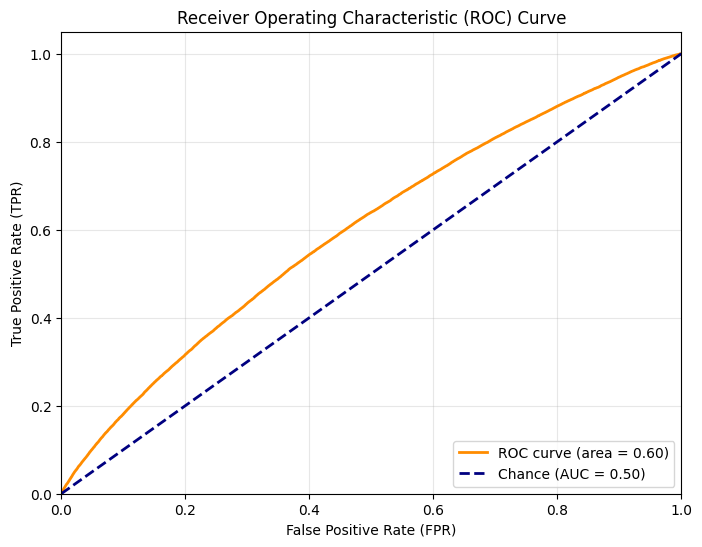

In [66]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get the predicted probabilities for the *positive class* (class 1)
# We need probabilities, not just the final 0/1 predictions
y_pred_proba = log_model.predict_proba(X_test)[:, 1]

# 2. Calculate the ROC curve points
# fpr = False Positive Rate
# tpr = True Positive Rate
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

# 3. Calculate the Area Under the Curve (AUC)
roc_auc = auc(fpr, tpr)

# 4. Plot the ROC curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, 
         label=f'ROC curve (area = {roc_auc:0.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', 
         label='Chance (AUC = 0.50)') # This is the "no-skill" line

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (FPR)')
plt.ylabel('True Positive Rate (TPR)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()